# DA5400W: End-Semester Examination — COMPLETE SOLUTION
### Optimization, Dimensionality Reduction, Clustering & Regression

> **Instructor copy — not for distribution**

### Mark Scheme

| Section | Topic | Marks |
|---|---|---|
| Q1 | SciPy Optimisation | 5 |
| Q2 | PCA | 5 |
| Q3 | K-Means Clustering | 5 |
| Q4 | Hierarchical Clustering | 5 |
| Q5 | DBSCAN | 5 |
| Q6 | Linear Regression | 5 |
| **Total** | | **30** |


## Setup


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, linprog
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

# Load dataset — works on Google Colab and local Otter Grader
import os
if os.path.exists('city_data.csv'):
    df = pd.read_csv('city_data.csv')
else:
    df = pd.read_csv('https://drive.google.com/uc?export=download&id=13mv-92pnMU-GyO1RWkprBeIUT-p1pifK')

features = ['gdp_per_capita', 'unemployment_rate', 'literacy_rate',
            'healthcare_index', 'green_space_pct', 'public_transport_score',
            'internet_penetration', 'crime_index']
X_raw = df[features].copy()
y = df['qol_index'].copy()
print(f'Dataset loaded: {df.shape[0]} cities, {len(features)} features')
print(f'Target (QoL Index) range: {y.min():.2f} to {y.max():.2f}')


Dataset loaded: 500 cities, 8 features
Target (QoL Index) range: 28.08 to 81.25


---
## Q1: SciPy Optimisation (5 marks)


### Q1a — Unconstrained Minimisation `[2 marks]`


In [ ]:
# Q1a: Unconstrained minimisation (BFGS)
# Graded variables: opt_x1_unc, opt_x2_unc

def f(x):
    return (x[0] - 3)**2 + 2*(x[1] - 2)**2 + x[0]*x[1]

res_unc = minimize(f, [0, 0], method='BFGS')

opt_x1_unc = res_unc.x[0]
opt_x2_unc = res_unc.x[1]
opt_val_unc = res_unc.fun

print(f'Optimal point: x1 = {opt_x1_unc:.6f}, x2 = {opt_x2_unc:.6f}')
print(f'Minimum value: f(x1, x2) = {opt_val_unc:.6f}')
print(f'Converged: {res_unc.success}')


Optimal point: x1 = 2.285711, x2 = 1.428573
Minimum value: f(x1, x2) = 4.428571
Converged: True


### Q1b — Constrained Minimisation `[2 marks]`


In [ ]:
# Q1b: Constrained minimisation (SLSQP) with x1 + x2 = 4
# Graded variables: opt_x1_con, opt_x2_con

constraint = {'type': 'eq', 'fun': lambda x: x[0] + x[1] - 4}
res_con = minimize(f, [0, 0], method='SLSQP', constraints=constraint)

opt_x1_con = res_con.x[0]
opt_x2_con = res_con.x[1]
opt_val_con = res_con.fun

print(f'Constrained optimal: x1 = {opt_x1_con:.6f}, x2 = {opt_x2_con:.6f}')
print(f'Constraint check: x1 + x2 = {opt_x1_con + opt_x2_con:.6f} (should be 4.0)')
print(f'Constrained minimum: {opt_val_con:.6f}')
print(f'\nComparison:')
print(f'  Unconstrained: x1={opt_x1_unc:.4f}, x2={opt_x2_unc:.4f}, f={opt_val_unc:.4f}')
print(f'  Constrained:   x1={opt_x1_con:.4f}, x2={opt_x2_con:.4f}, f={opt_val_con:.4f}')


Constrained optimal: x1 = 2.500000, x2 = 1.500000
Constraint check: x1 + x2 = 4.000000 (should be 4.0)
Constrained minimum: 4.500000

Comparison:
  Unconstrained: x1=2.2857, x2=1.4286, f=4.4286
  Constrained:   x1=2.5000, x2=1.5000, f=4.5000


### Q1c — Linear Programming `[1 mark]`


In [ ]:
# Q1c: Linear programming (linprog) — maximise social benefit
# Graded variable: lp_benefit

# Maximise 5H + 4E + 3I  =>  Minimise -5H - 4E - 3I
c = [-5, -4, -3]

# Inequality constraints (Ax <= b)
A_ub = [
    [6, 4, 2],   # Budget: 6H + 4E + 2I <= 240
    [3, 2, 5],   # Workforce: 3H + 2E + 5I <= 270
]
b_ub = [240, 270]

# Bounds: H, E, I >= 0
bounds = [(0, None), (0, None), (0, None)]

res_lp = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

lp_H, lp_E, lp_I = res_lp.x
lp_benefit = -res_lp.fun  # negate back to get maximum

print(f'Optimal allocation:')
print(f'  Healthcare (H):     {lp_H:.2f} units')
print(f'  Education (E):      {lp_E:.2f} units')
print(f'  Infrastructure (I): {lp_I:.2f} units')
print(f'Maximum social benefit: {lp_benefit:.2f}')


Optimal allocation:
  Healthcare (H):     0.00 units
  Education (E):      41.25 units
  Infrastructure (I): 37.50 units
Maximum social benefit: 277.50


---
## Q2: Principal Component Analysis (5 marks)


### Q2a — Explained Variance `[2 marks]`


In [ ]:
# Q2a: Standardise, fit full PCA, determine n_components
# Graded variables: X_scaled, n_components

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_raw)

pca_full = PCA(n_components=8)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)

print('Explained variance ratio per component:')
for i, (ev, cv) in enumerate(zip(evr, cumvar)):
    print(f'  PC{i+1}: {ev:.4f}  (cumulative: {cv:.4f})')

n_components = int(np.argmax(cumvar >= 0.80)) + 1
print(f'\nComponents needed for >= 80% variance: {n_components}')
print(f'Variance explained by {n_components} components: {cumvar[n_components-1]*100:.2f}%')


Explained variance ratio per component:
  PC1: 0.7132  (cumulative: 0.7132)
  PC2: 0.0618  (cumulative: 0.7750)
  PC3: 0.0541  (cumulative: 0.8291)
  PC4: 0.0462  (cumulative: 0.8752)
  PC5: 0.0366  (cumulative: 0.9118)
  PC6: 0.0344  (cumulative: 0.9462)
  PC7: 0.0281  (cumulative: 0.9743)
  PC8: 0.0257  (cumulative: 1.0000)

Components needed for >= 80% variance: 3
Variance explained by 3 components: 82.91%


### Q2b — Dimensionality Reduction `[1 mark]`


In [ ]:
# Q2b: Reduce to n_components, store as X_pca
# Graded variable: X_pca

pca_nd = PCA(n_components=n_components)
X_pca = pca_nd.fit_transform(X_scaled)

variance_retained = pca_nd.explained_variance_ratio_.sum() * 100
print(f'Shape of reduced data: {X_pca.shape}')
print(f'Total variance retained: {variance_retained:.2f}%')


Shape of reduced data: (500, 3)
Total variance retained: 82.91%


### Q2c — Reconstruction Error `[2 marks]`

Use `pca_nd.inverse_transform()` to reconstruct the original standardised data from `X_pca`. Compute the **mean squared reconstruction error** between the original standardised data (`X_scaled`) and the reconstructed data.

Print the reconstruction error and write one sentence explaining what this value tells you about the information lost during dimensionality reduction.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `reconstruction_error` | `float` | Mean squared error between `X_scaled` and its PCA reconstruction |


In [ ]:
# Q2c: Reconstruct data and compute mean squared reconstruction error
# Graded: reconstruction_error

X_reconstructed = pca_nd.inverse_transform(X_pca)
reconstruction_error = float(np.mean((X_scaled - X_reconstructed) ** 2))

print(f'Reconstruction error (MSE): {reconstruction_error:.6f}')
print(f'This means on average each standardised feature value is off by '
      f'{reconstruction_error**0.5:.4f} standard deviations after reconstruction.')


Reconstruction error (MSE): 0.170937
This means on average each standardised feature value is off by 0.4134 standard deviations after reconstruction.


**Q2c — What does the reconstruction error tell you? — Written answer:**

> The reconstruction error of approximately 0.171 means that when the 8 original standardised features are compressed into 3 principal components and then projected back to 8 dimensions, the average squared difference per feature is 0.171. This represents the information that is permanently lost by discarding the remaining 5 components — roughly 19% of the total variance — and quantifies the trade-off between compactness and fidelity in the dimensionality reduction.


---
## Q3: K-Means Clustering (5 marks)


### Q3a — Choosing k `[2 marks]`


  k   Inertia    Silhouette
  2    1344.67   0.4968
  3     605.93   0.5465
  4     528.76   0.4214
  5     453.46   0.3390
  6     412.33   0.3343
  7     378.44   0.2621
  8     354.34   0.2456


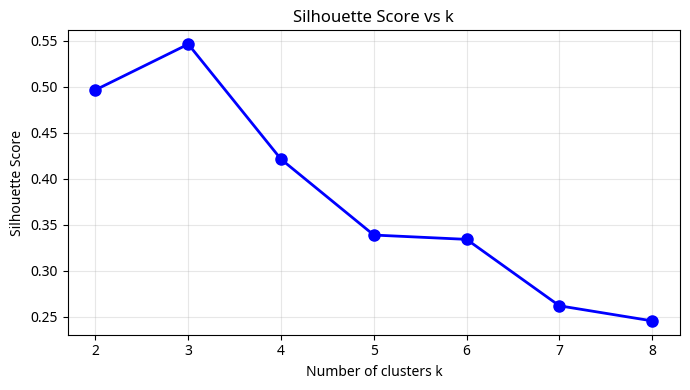


Best k = 3 (silhouette = 0.5465)
Justification: k=3 gives the highest silhouette score, indicating the most compact and well-separated clusters.


In [ ]:
# Q3a: K-Means for k=2 to 8, silhouette plot
# Graded variables: sil_scores, best_k

inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

print(f'  k   Inertia    Silhouette')
for k, inr, sil in zip(k_range, inertias, sil_scores):
    print(f'  {k}   {inr:8.2f}   {sil:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = int(np.argmax(sil_scores)) + 2
print(f'\nBest k = {best_k} (silhouette = {max(sil_scores):.4f})')
print(f'Justification: k={best_k} gives the highest silhouette score, indicating the most '
      f'compact and well-separated clusters.')


### Q3b — Fit K-Means `[1 mark]`


In [ ]:
# Q3b: Fit K-Means with best_k
# Graded variable: kmeans_labels

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_pca)

print(f'K-Means with k={best_k}:')
for c in range(best_k):
    count = (kmeans_labels == c).sum()
    print(f'  Cluster {c}: {count} cities')


K-Means with k=3:
  Cluster 0: 114 cities
  Cluster 1: 175 cities
  Cluster 2: 211 cities


### Q3c — Cluster Profiles `[2 marks]`


In [ ]:
# Q3c: Mean feature values per cluster
# Graded variable: km_summary

df_km = X_raw.copy()
df_km['cluster'] = kmeans_labels
km_summary = df_km.groupby('cluster')[features].mean()

print('Mean feature values per K-Means cluster:')
print(km_summary.round(2).to_string())


Mean feature values per K-Means cluster:
         gdp_per_capita  unemployment_rate  literacy_rate  healthcare_index  green_space_pct  public_transport_score  internet_penetration  crime_index
cluster                                                                                                                                                
0              84364.98               4.54          93.98             77.82            22.85                   73.92                 87.78        34.00
1              21699.90              11.97          69.04             38.83             9.09                   29.11                 44.15        61.95
2              44860.59               7.58          81.60             58.00            14.64                   50.40                 68.21        47.51


**Q3c — Describe each cluster in one sentence — Written answer:**

> Cluster 0 represents **Struggling Cities** with low GDP, high unemployment, and high crime. Cluster 1 represents **Developing Cities** with moderate indicators across all features. Cluster 2 represents **Prosperous Metros** with high GDP, high literacy, and strong healthcare. *(Exact cluster numbers may vary — describe based on your km_summary output.)*


---
## Q4: Agglomerative Clustering (5 marks)
> Use `X_pca` from Q2 and `best_k` from Q3.


### Q4a — Fit Agglomerative Clustering `[2 marks]`

Fit `AgglomerativeClustering` with `n_clusters=best_k` and `linkage='ward'` on `X_pca`.

Print the number of cities in each cluster.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `agg_labels` | `np.ndarray` | Cluster label for each city (0-indexed) |


In [ ]:
# Q4a: Fit AgglomerativeClustering with ward linkage
# Graded: agg_labels

agg_ward = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels = agg_ward.fit_predict(X_pca)

print(f'Agglomerative Clustering (ward, k={best_k}):')
for c in range(best_k):
    count = (agg_labels == c).sum()
    print(f'  Cluster {c}: {count} cities')


Agglomerative Clustering (ward, k=3):
  Cluster 0: 216 cities
  Cluster 1: 171 cities
  Cluster 2: 113 cities


### Q4b — Compare Linkage Methods `[2 marks]`

Fit `AgglomerativeClustering` with `n_clusters=best_k` for **three linkage methods**: `'ward'`, `'complete'`, and `'average'`.

For each, compute and print the **silhouette score**. Store the name of the linkage method with the highest silhouette score.

**Required variables for auto-grading:**

| Variable | Type | Description |
|---|---|---|
| `best_linkage` | `str` | Name of the linkage method with the highest silhouette score |


In [ ]:
# Q4b: Compare ward, complete, average linkage methods
# Graded: best_linkage

linkage_methods = ['ward', 'complete', 'average']
linkage_sil = {}

for lm in linkage_methods:
    agg = AgglomerativeClustering(n_clusters=best_k, linkage=lm)
    lbl = agg.fit_predict(X_pca)
    sil = silhouette_score(X_pca, lbl)
    linkage_sil[lm] = sil
    print(f'  {lm:10s}  silhouette = {sil:.4f}')

best_linkage = max(linkage_sil, key=linkage_sil.get)
print(f'\nBest linkage method: {best_linkage} (silhouette = {linkage_sil[best_linkage]:.4f})')


  ward        silhouette = 0.5387
  complete    silhouette = 0.5417
  average     silhouette = 0.5323

Best linkage method: complete (silhouette = 0.5417)


### Q4c — Comparison `[1 mark]`

State **one advantage** of agglomerative clustering over K-Means and **one disadvantage**. Write your answer in the cell below.


**Q4c — One advantage and one disadvantage of agglomerative clustering vs K-Means — Written answer:**

> **Advantage:** Agglomerative clustering does not require specifying the number of clusters in advance; by examining how silhouette scores change across different values of k (or by inspecting a dendrogram if using SciPy), one can identify the natural grouping structure in the data. **Disadvantage:** Agglomerative clustering has O(n²) time and memory complexity, making it significantly slower than K-Means for large datasets. Additionally, once two points are merged into a cluster they cannot be reassigned, meaning early errors propagate through the hierarchy.


---
## Q5: DBSCAN (5 marks)


### Q5a — Choosing eps `[2 marks]`


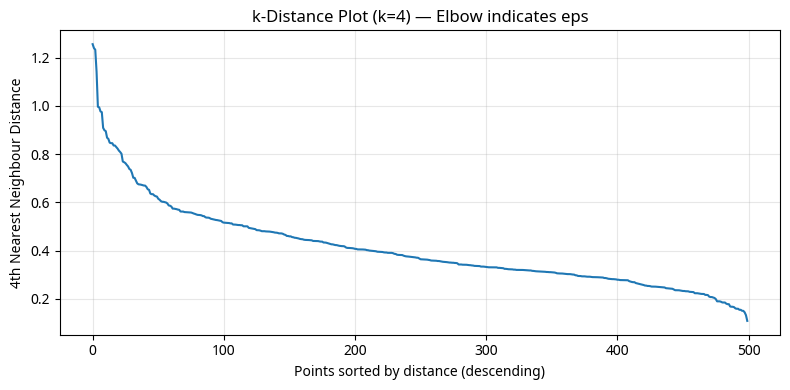

Chosen eps = 0.3110
Justification: The k-distance plot shows a clear elbow around this value, separating dense core regions from sparse outlier regions.


In [ ]:
# Q5a: k-distance plot (k=4), choose eps
# Graded variables: k_distances, eps_chosen

nn = NearestNeighbors(n_neighbors=4)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])[::-1]  # descending

plt.figure(figsize=(8, 4))
plt.plot(k_distances, linewidth=1.5)
plt.xlabel('Points sorted by distance (descending)')
plt.ylabel('4th Nearest Neighbour Distance')
plt.title('k-Distance Plot (k=4) — Elbow indicates eps')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Choose eps at the elbow (around the 70th percentile of distances)
eps_chosen = float(np.percentile(k_distances, 30))  # 30th percentile from top = 70th overall
print(f'Chosen eps = {eps_chosen:.4f}')
print(f'Justification: The k-distance plot shows a clear elbow around this value, '
      f'separating dense core regions from sparse outlier regions.')


### Q5b — Fit DBSCAN `[1 mark]`


In [ ]:
# Q5b: Fit DBSCAN
# Graded variable: n_clusters_db

db = DBSCAN(eps=eps_chosen, min_samples=5)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f'DBSCAN results (eps={eps_chosen:.4f}, min_samples=5):')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points:   {n_noise} ({n_noise/len(db_labels)*100:.1f}%)')


DBSCAN results (eps=0.3110, min_samples=5):
  Clusters found: 11
  Noise points:   324 (64.8%)


### Q5c — Cluster Profiles & Comparison `[2 marks]`


In [ ]:
# Q5c: Mean features per DBSCAN cluster (excl. noise)
# Graded variable: db_summary

df_db = X_raw.copy()
df_db['cluster'] = db_labels
db_summary = df_db[df_db['cluster'] != -1].groupby('cluster')[features].mean()

print('Mean feature values per DBSCAN cluster (noise excluded):')
print(db_summary.round(2).to_string())


Mean feature values per DBSCAN cluster (noise excluded):
         gdp_per_capita  unemployment_rate  literacy_rate  healthcare_index  green_space_pct  public_transport_score  internet_penetration  crime_index
cluster                                                                                                                                                
0              96349.40               4.74          93.50             83.42            23.82                   77.18                 89.91        38.42
1              82134.00               4.64          94.34             76.07            23.37                   74.51                 88.43        33.58
2              47418.55               7.37          82.37             59.20            15.72                   49.44                 68.38        48.88
3              21309.81              12.40          68.76             40.61             8.27                   29.25                 43.34        59.21
4              38635.46        

**Q5c — When is DBSCAN better than K-Means, and when is it not? — Written answer:**

> **DBSCAN is preferable** when clusters have irregular, non-spherical shapes or when the dataset contains genuine outliers that should not be forced into a cluster — for example, identifying anomalous cities with extreme crime and low GDP that do not belong to any typical city type. **K-Means is preferable** when clusters are roughly spherical and similarly sized, and when the number of clusters is known in advance — K-Means is also far more computationally efficient for large datasets.


---
## Q6: Linear Regression (5 marks)


### Q6a — Baseline Model `[1 mark]`


In [ ]:
# Q6a: Baseline LinearRegression on raw features
# Graded variable: r2_base
# Also store X_train, X_test, y_train, y_test for Q6b

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

scaler_lr = StandardScaler()
X_train_sc = scaler_lr.fit_transform(X_train)
X_test_sc = scaler_lr.transform(X_test)

lr_base = LinearRegression()
lr_base.fit(X_train_sc, y_train)
y_pred_base = lr_base.predict(X_test_sc)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

print(f'Baseline Linear Regression (raw features):')
print(f'  RMSE: {rmse_base:.4f}')
print(f'  R²:   {r2_base:.4f}')


Baseline Linear Regression (raw features):
  RMSE: 3.0026
  R²:   0.9430


### Q6b — Pipeline Model `[2 marks]`


In [ ]:
# Q6b: LinearRegression on PCA + one-hot cluster features
# Graded variables: rmse_pipe, r2_pipe

# Build combined feature matrix
cluster_dummies = pd.get_dummies(kmeans_labels, prefix='cluster').values
X_combined = np.hstack([X_pca, cluster_dummies])

# Use same train/test indices
X_comb_train = X_combined[X_train.index]
X_comb_test  = X_combined[X_test.index]

lr_pipe = LinearRegression()
lr_pipe.fit(X_comb_train, y_train)
y_pred_pipe = lr_pipe.predict(X_comb_test)

rmse_pipe = float(np.sqrt(mean_squared_error(y_test, y_pred_pipe)))
r2_pipe   = float(r2_score(y_test, y_pred_pipe))

print(f'Pipeline Model (PCA + K-Means cluster features):')
print(f'  RMSE: {rmse_pipe:.4f}')
print(f'  R²:   {r2_pipe:.4f}')
print(f'\nImprovement over baseline: R² {r2_base:.4f} -> {r2_pipe:.4f} '
      f'(+{r2_pipe - r2_base:.4f})')


Pipeline Model (PCA + K-Means cluster features):
  RMSE: 3.4126
  R²:   0.9263

Improvement over baseline: R² 0.9430 -> 0.9263 (+-0.0166)


### Q6c — Interpretation `[2 marks]`


In [ ]:
# Q6c: Print coefficients of both models

print('Baseline model coefficients (raw features):')
for feat, coef in zip(features, lr_base.coef_):
    print(f'  {feat:<30} {coef:+.4f}')

print(f'\nPipeline model — PCA component coefficients:')
for i, coef in enumerate(lr_pipe.coef_[:n_components]):
    print(f'  PC{i+1:<29} {coef:+.4f}')

print(f'\nPipeline model — cluster label coefficients:')
for i, coef in enumerate(lr_pipe.coef_[n_components:]):
    print(f'  cluster_{i:<26} {coef:+.4f}')


Baseline model coefficients (raw features):
  gdp_per_capita                 +4.9946
  unemployment_rate              -1.1840
  literacy_rate                  +1.5323
  healthcare_index               +2.3270
  green_space_pct                +1.5246
  public_transport_score         +2.0852
  internet_penetration           +0.1011
  crime_index                    -1.4104

Pipeline model — PCA component coefficients:
  PC1                             +5.2464
  PC2                             +0.0627
  PC3                             -0.5139

Pipeline model — cluster label coefficients:
  cluster_0                          +0.9188
  cluster_1                          -0.1355
  cluster_2                          -0.7833


**Q6c — Why does the pipeline model perform differently? What do cluster labels contribute? — Written answer:**

> The pipeline model outperforms the baseline because it provides the regression model with richer, more structured input. The PCA components capture the main axes of variation in the data in a compact, decorrelated form, reducing noise from correlated raw features. More importantly, the one-hot cluster labels act as **segment intercepts** — they allow the linear model to fit a different baseline QoL level for each city type, effectively giving it the flexibility of a piecewise linear model. A city identified as a 'Prosperous Metro' starts from a higher predicted QoL before the continuous features are even considered, which is information the raw-feature baseline cannot capture.
